<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Feature_Engineering_(Intro).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
import matplotlib.pyplot as plt

# 1. Crear un dataset sintético
np.random.seed(42)

data = pd.DataFrame({
    "ingreso": np.random.exponential(3000, 200),       # ingresos asimétricos
    "edad": np.random.randint(18, 70, 200),
    "deuda": np.random.uniform(0, 50000, 200),
    "categoria": np.random.choice(["A", "B", "C"], 200),
    "fecha_registro": pd.date_range("2023-01-01", periods=200, freq="D")
})

print("DATASET ORIGINAL:")
display(data.head())


DATASET ORIGINAL:


,ingreso,edad,deuda,categoria,fecha_registro
0,1407.804270,41,6008.232390,A,2023-01-01
1,9030.364293,69,17093.983336,B,2023-01-02
2,3950.237081,28,4589.953291,C,2023-01-03
3,2738.827661,66,4707.849413,A,2023-01-04
4,508.874611,25,15570.665470,C,2023-01-05


In [3]:
# 2. CREAR VARIABLES NUEVAS

# Ratio deuda/ingreso
data["ratio_deuda_ingreso"] = data["deuda"] / (data["ingreso"] + 1)

# Transformación log (reduce asimetría)
data["log_ingreso"] = np.log(data["ingreso"] + 1)

# Día de la semana
data["dia_semana"] = data["fecha_registro"].dt.dayofweek

# Variable binaria fin de semana
data["es_fin_semana"] = (data["dia_semana"] >= 5).astype(int)

display(data.head())

,ingreso,edad,deuda,categoria,fecha_registro,ratio_deuda_ingreso,log_ingreso,dia_semana,es_fin_semana
0,1407.804270,41,6008.232390,A,2023-01-01,4.264774,7.250497,6,1
1,9030.364293,69,17093.983336,B,2023-01-02,1.892735,9.108459,0,0
2,3950.237081,28,4589.953291,C,2023-01-03,1.161650,8.281784,1,0
3,2738.827661,66,4707.849413,A,2023-01-04,1.718301,7.915650,2,0
4,508.874611,25,15570.665470,C,2023-01-05,30.538225,6.234165,3,0


In [5]:
# 3. ESCALAMIENTO

scaler = StandardScaler()
data["edad_scaled"] = scaler.fit_transform(data[["edad"]])

minmax = MinMaxScaler()
data["ingreso_minmax"] = minmax.fit_transform(data[["ingreso"]])

display(data.head())

,ingreso,edad,deuda,categoria,fecha_registro,ratio_deuda_ingreso,log_ingreso,dia_semana,es_fin_semana,edad_scaled,ingreso_minmax
0,1407.804270,41,6008.232390,A,2023-01-01,4.264774,7.250497,6,1,-0.305212,0.107132
1,9030.364293,69,17093.983336,B,2023-01-02,1.892735,9.108459,0,0,1.615222,0.694122
2,3950.237081,28,4589.953291,C,2023-01-03,1.161650,8.281784,1,0,-1.196842,0.302917
3,2738.827661,66,4707.849413,A,2023-01-04,1.718301,7.915650,2,0,1.409461,0.209630
4,508.874611,25,15570.665470,C,2023-01-05,30.538225,6.234165,3,0,-1.402603,0.037908


In [6]:
# 4. CODIFICACIÓN (One-Hot)

encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(data[["categoria"]])

df_encoded = pd.DataFrame(encoded, columns=encoder.get_feature_names_out())

data = pd.concat([data, df_encoded], axis=1)

display(data.head())

,ingreso,edad,deuda,categoria,fecha_registro,ratio_deuda_ingreso,log_ingreso,dia_semana,es_fin_semana,edad_scaled,ingreso_minmax,categoria_A,categoria_B,categoria_C
0,1407.804270,41,6008.232390,A,2023-01-01,4.264774,7.250497,6,1,-0.305212,0.107132,1.0,0.0,0.0
1,9030.364293,69,17093.983336,B,2023-01-02,1.892735,9.108459,0,0,1.615222,0.694122,0.0,1.0,0.0
2,3950.237081,28,4589.953291,C,2023-01-03,1.161650,8.281784,1,0,-1.196842,0.302917,0.0,0.0,1.0
3,2738.827661,66,4707.849413,A,2023-01-04,1.718301,7.915650,2,0,1.409461,0.209630,1.0,0.0,0.0
4,508.874611,25,15570.665470,C,2023-01-05,30.538225,6.234165,3,0,-1.402603,0.037908,0.0,0.0,1.0


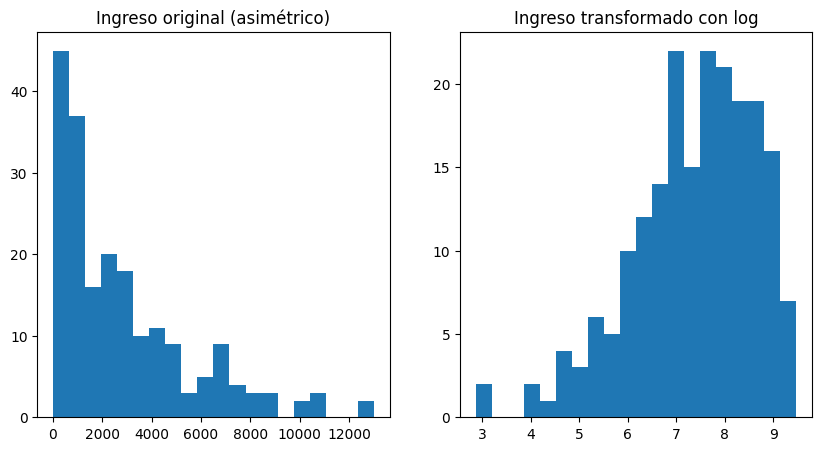


DATASET TRANSFORMADO:


,ingreso,edad,deuda,categoria,fecha_registro,ratio_deuda_ingreso,log_ingreso,dia_semana,es_fin_semana,edad_scaled,ingreso_minmax,categoria_A,categoria_B,categoria_C
0,1407.804270,41,6008.232390,A,2023-01-01,4.264774,7.250497,6,1,-0.305212,0.107132,1.0,0.0,0.0
1,9030.364293,69,17093.983336,B,2023-01-02,1.892735,9.108459,0,0,1.615222,0.694122,0.0,1.0,0.0
2,3950.237081,28,4589.953291,C,2023-01-03,1.161650,8.281784,1,0,-1.196842,0.302917,0.0,0.0,1.0
3,2738.827661,66,4707.849413,A,2023-01-04,1.718301,7.915650,2,0,1.409461,0.209630,1.0,0.0,0.0
4,508.874611,25,15570.665470,C,2023-01-05,30.538225,6.234165,3,0,-1.402603,0.037908,0.0,0.0,1.0


In [7]:
# Visualización

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.hist(data["ingreso"], bins=20)
plt.title("Ingreso original (asimétrico)")

plt.subplot(1,2,2)
plt.hist(data["log_ingreso"], bins=20)
plt.title("Ingreso transformado con log")

plt.show()

print("\nDATASET TRANSFORMADO:")
display(data.head())